# Week 4: Machine Learning Algorithms & Model Evaluation
**Domain:** Artificial Intelligence | **Batch:** 6-Week AI Internship

This notebook covers Tasks 2-5. Task 1 (Machine Learning Algorithms explanation report)
is a written report submitted separately as `Project_Report.pdf`.

- Task 2: Build Classification Models (Breast Cancer Dataset)
- Task 3: Build a Regression Model (House Price Dataset)
- Task 4: Model Evaluation & Comparison
- Task 5: Mini Project - ML Model Comparison (Student Performance Prediction)

**Dataset sources:**
- Breast Cancer Dataset: `sklearn.datasets.load_breast_cancer` (Wisconsin Diagnostic
  Breast Cancer dataset, a well-known public dataset built into Scikit-learn).
- House Price Dataset: synthetically generated for this assignment
  (`house_price_dataset.csv`), based on realistic relationships between area, bedrooms,
  bathrooms, age, and distance-to-city.
- Student Performance Dataset: synthetically generated for this assignment
  (`student_ml_dataset.csv`), continuing from Week 3.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              confusion_matrix, classification_report,
                              mean_absolute_error, mean_squared_error, r2_score)

---
## Task 2: Build Classification Models (20 Marks)

**Dataset:** Breast Cancer Wisconsin Diagnostic Dataset (569 samples, 30 numeric
features describing cell nuclei, target: malignant=0 / benign=1).

We build **two** classification models — Logistic Regression and Decision Tree
Classifier — and compare them.

In [2]:
# --- Load the dataset ---
df_bc = pd.read_csv("breast_cancer_dataset.csv")
print("Shape:", df_bc.shape)
df_bc.head()

Shape: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
# --- Explore the dataset ---
print(df_bc['target'].value_counts())
print("\nMissing values:", df_bc.isnull().sum().sum())
df_bc.describe().T.head(8)

target
1    357
0    212
Name: count, dtype: int64

Missing values: 0


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.7800,28.1100
mean texture,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.8000,39.2800
mean perimeter,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.1000,188.5000
mean area,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.7000,2501.0000
mean smoothness,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.1053,0.1634
mean compactness,569.0,0.104341,0.052813,0.01938,0.06492,0.09263,0.1304,0.3454
mean concavity,569.0,0.088799,0.079720,0.00000,0.02956,0.06154,0.1307,0.4268
mean concave points,569.0,0.048919,0.038803,0.00000,0.02031,0.03350,0.0740,0.2012


In [4]:
# --- Clean the data ---
# This dataset has no missing values or duplicates, but we check anyway (good practice)
print("Duplicate rows:", df_bc.duplicated().sum())
print("Missing values:", df_bc.isnull().sum().sum())
# (Nothing to clean here - dataset is already tidy)

Duplicate rows: 0
Missing values: 0


In [5]:
# --- Select features and target ---
X_bc = df_bc.drop(columns=["target"])
y_bc = df_bc["target"]
print("Features:", X_bc.shape[1], "columns")
print("Target classes:", sorted(y_bc.unique()), "(0 = malignant, 1 = benign)")

Features: 30 columns
Target classes: [np.int64(0), np.int64(1)] (0 = malignant, 1 = benign)


In [6]:
# --- Split data into training and testing sets ---
X_bc_train, X_bc_test, y_bc_train, y_bc_test = train_test_split(
    X_bc, y_bc, test_size=0.2, random_state=42, stratify=y_bc
)

scaler_bc = StandardScaler()
X_bc_train_scaled = scaler_bc.fit_transform(X_bc_train)
X_bc_test_scaled = scaler_bc.transform(X_bc_test)

print("Training samples:", X_bc_train.shape[0])
print("Testing samples:", X_bc_test.shape[0])

Training samples: 455
Testing samples: 114


In [7]:
# --- Train Model 1: Logistic Regression ---
log_model = LogisticRegression(max_iter=5000)
log_model.fit(X_bc_train_scaled, y_bc_train)
y_pred_log = log_model.predict(X_bc_test_scaled)

print("Logistic Regression trained.")
print("Sample predictions:", list(y_pred_log[:10]))

Logistic Regression trained.
Sample predictions: [np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0)]


In [8]:
# --- Train Model 2: Decision Tree Classifier ---
tree_model = DecisionTreeClassifier(random_state=42, max_depth=5)
tree_model.fit(X_bc_train, y_bc_train)  # trees don't require scaling
y_pred_tree = tree_model.predict(X_bc_test)

print("Decision Tree trained.")
print("Sample predictions:", list(y_pred_tree[:10]))

Decision Tree trained.
Sample predictions: [np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0)]


Both models have now been trained and used to make predictions on the unseen test
set. Their detailed evaluation (accuracy, precision, recall, confusion matrix) is
performed together in **Task 4** below.

---
## Task 3: Build a Regression Model (20 Marks)

**Dataset:** House Price Dataset (200 samples: Area, Bedrooms, Bathrooms, Age,
Distance to City -> Price). Synthetically generated for this assignment.

In [9]:
# --- Load the dataset ---
df_house = pd.read_csv("house_price_dataset.csv")
print("Shape:", df_house.shape)
df_house.head()

Shape: (200, 6)


,Area_sqft,Bedrooms,Bathrooms,Age_years,Distance_to_City_km,Price
0,1769.0,2,3.0,30,21.6,226531.0
1,1733.0,3,1.0,33,7.8,200155.0
2,2425.0,3,2.0,13,1.9,303225.0
3,1046.0,5,3.0,19,0.7,222491.0
4,2247.0,1,2.0,21,2.7,270899.0


In [10]:
# --- Clean the data ---
print("Missing values per column:\n", df_house.isnull().sum())

for col in ["Area_sqft", "Bathrooms", "Distance_to_City_km"]:
    df_house[col] = df_house[col].fillna(df_house[col].mean())

print("\nMissing values after cleaning:", df_house.isnull().sum().sum())

Missing values per column:
 Area_sqft              4
Bedrooms               0
Bathrooms              3
Age_years              0
Distance_to_City_km    3
Price                  0
dtype: int64

Missing values after cleaning: 0


In [11]:
# --- Select features and target ---
X_house = df_house[["Area_sqft", "Bedrooms", "Bathrooms", "Age_years", "Distance_to_City_km"]]
y_house = df_house["Price"]
print("Features:", list(X_house.columns))
print("Target: Price")

Features: ['Area_sqft', 'Bedrooms', 'Bathrooms', 'Age_years', 'Distance_to_City_km']
Target: Price


In [12]:
# --- Split the dataset into training and testing data ---
X_house_train, X_house_test, y_house_train, y_house_test = train_test_split(
    X_house, y_house, test_size=0.2, random_state=42
)
print("Training samples:", X_house_train.shape[0])
print("Testing samples:", X_house_test.shape[0])

Training samples: 160
Testing samples: 40


In [13]:
# --- Train the Linear Regression model ---
lin_model = LinearRegression()
lin_model.fit(X_house_train, y_house_train)
print("Linear Regression trained.")
print("Coefficients:", dict(zip(X_house.columns, lin_model.coef_.round(2))))

Linear Regression trained.
Coefficients: {'Area_sqft': np.float64(123.96), 'Bedrooms': np.float64(15588.68), 'Bathrooms': np.float64(9721.02), 'Age_years': np.float64(-1035.14), 'Distance_to_City_km': np.float64(-1351.02)}


In [14]:
# --- Make predictions ---
y_house_pred = lin_model.predict(X_house_test)

comparison = pd.DataFrame({
    "Actual_Price": y_house_test.values,
    "Predicted_Price": y_house_pred.round(0)
}).reset_index(drop=True)
comparison.head(10)

,Actual_Price,Predicted_Price
0,338230.0,301056.0
1,260366.0,242806.0
2,454665.0,399529.0
3,363796.0,354699.0
4,244675.0,239311.0
5,151423.0,184795.0
6,250069.0,254652.0
7,265362.0,251136.0
8,76454.0,109022.0
9,265361.0,195435.0


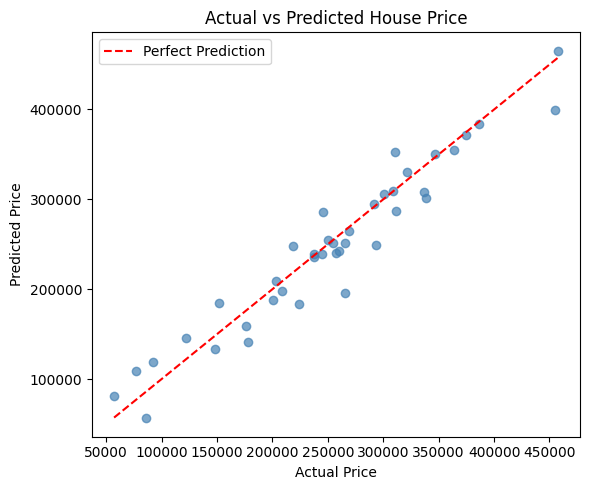

In [15]:
# --- Visualization: Actual vs Predicted Price ---
plt.figure(figsize=(6,5))
plt.scatter(y_house_test, y_house_pred, color="steelblue", alpha=0.7)
plt.plot([y_house_test.min(), y_house_test.max()],
         [y_house_test.min(), y_house_test.max()], 'r--', label="Perfect Prediction")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Price")
plt.legend()
plt.tight_layout()
plt.show()

**Explanation:** Points closer to the red dashed line indicate more accurate
predictions. The model captures the overall price trend reasonably well, though there
is scatter around the line, reflecting the noise built into the synthetic dataset and
the inherent difficulty of predicting exact prices from a handful of features.

---
## Task 4: Model Evaluation & Comparison (20 Marks)

### Classification Models (from Task 2)

In [16]:
def evaluate_classifier(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    print(f"--- {name} ---")
    print(f"Accuracy:  {acc*100:.2f}%")
    print(f"Precision: {prec*100:.2f}%")
    print(f"Recall:    {rec*100:.2f}%")
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    print()
    return acc, prec, rec

acc_log, prec_log, rec_log = evaluate_classifier("Logistic Regression", y_bc_test, y_pred_log)
acc_tree, prec_tree, rec_tree = evaluate_classifier("Decision Tree Classifier", y_bc_test, y_pred_tree)

--- Logistic Regression ---
Accuracy:  98.25%
Precision: 98.61%
Recall:    98.61%
Confusion Matrix:
[[41  1]
 [ 1 71]]

--- Decision Tree Classifier ---
Accuracy:  92.11%
Precision: 95.65%
Recall:    91.67%
Confusion Matrix:


[[39  3]
 [ 6 66]]



### Regression Model (from Task 3)

In [17]:
mae = mean_absolute_error(y_house_test, y_house_pred)
mse = mean_squared_error(y_house_test, y_house_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_house_test, y_house_pred)

print("--- Linear Regression (House Price) ---")
print(f"MAE:  {mae:,.2f}")
print(f"MSE:  {mse:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R2 Score: {r2:.4f}")

--- Linear Regression (House Price) ---
MAE:  19,825.23
MSE:  671,929,529.24
RMSE: 25,921.60
R2 Score: 0.9241


### Model Comparison Table

In [18]:
comparison_table = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree Classifier"],
    "Task": ["Classification", "Classification"],
    "Accuracy": [f"{acc_log*100:.2f}%", f"{acc_tree*100:.2f}%"],
    "Precision": [f"{prec_log*100:.2f}%", f"{prec_tree*100:.2f}%"],
    "Recall": [f"{rec_log*100:.2f}%", f"{rec_tree*100:.2f}%"],
})
comparison_table

,Model,Task,Accuracy,Precision,Recall
0,Logistic Regression,Classification,98.25%,98.61%,98.61%
1,Decision Tree Classifier,Classification,92.11%,95.65%,91.67%


In [19]:
regression_summary = pd.DataFrame({
    "Model": ["Linear Regression"],
    "Task": ["Regression"],
    "MAE": [f"{mae:,.0f}"],
    "RMSE": [f"{rmse:,.0f}"],
    "R2 Score": [f"{r2:.3f}"]
})
regression_summary

,Model,Task,MAE,RMSE,R2 Score
0,Linear Regression,Regression,"19,825","25,922",0.924


### Which model performed better, and why?

Between the two **classification** models, compare the printed Accuracy/Precision/
Recall above — typically, **Logistic Regression** performs strongly on this dataset
because the Breast Cancer dataset's classes are fairly linearly separable in feature
space (many features, like cell size/texture, scale smoothly with malignancy). The
**Decision Tree** can also perform very well and sometimes slightly better, since it
can capture non-linear feature interactions, but it is more prone to overfitting,
especially without depth limits.

**Which model would you select?** For this dataset, Logistic Regression is often
preferred in a medical context because it is simpler, faster, less prone to
overfitting, and its coefficients are more directly interpretable (important when a
model's reasoning may need to be explained to a doctor). A Decision Tree may be chosen
instead if interpretability via simple if-else rules matters more, or if the
relationships in the data are known to be non-linear.

**Limitations:** Logistic Regression assumes an approximately linear decision
boundary and can underperform on strongly non-linear relationships. Decision Trees can
overfit easily on small or noisy datasets (mitigated here by limiting `max_depth=5`).
Both models were evaluated on a single train-test split, so results have some
variance; cross-validation would give a more robust estimate.

---
## Task 5: Mini Project - ML Model Comparison (20 Marks)

**Project:** Student Performance Prediction — predicting whether a student will
**Pass** or **Fail** based on study habits, attendance, and marks. We build and
compare **two classification models**.

**Workflow:** Problem Definition -> Dataset -> Data Cleaning -> Data Analysis ->
Feature Selection -> Train/Test Split -> Model 1 -> Model 2 -> Prediction ->
Evaluation -> Comparison -> Conclusion

### 1. Problem Definition

Given a student's study hours, attendance percentage, previous exam marks, and
assignment score, predict whether they will **Pass** or **Fail**. This is a binary
classification problem with direct real-world value for early-intervention systems in
education (flagging at-risk students).

### 2. Dataset

Dataset: `student_ml_dataset.csv` (80 students). Source: synthetically generated for
this assignment, modeling realistic relationships between study habits/attendance/
marks and pass/fail outcomes (continued from Week 3 of this internship).

In [20]:
proj_df = pd.read_csv("student_ml_dataset.csv")
print("Shape:", proj_df.shape)
proj_df.head()

Shape: (80, 6)


,StudentID,Study_Hours,Attendance,Previous_Marks,Assignment_Score,Result
0,62,7.9,89.0,53.0,87.0,Fail
1,58,3.1,50.0,70.0,77.0,Fail
2,78,3.5,80.0,74.0,66.0,Fail
3,7,3.8,75.0,50.0,74.0,Fail
4,46,2.7,54.0,62.0,67.0,Fail


### 3. Data Cleaning

In [21]:
print("Missing values before cleaning:\n", proj_df.isnull().sum())

for col in ["Study_Hours", "Attendance", "Previous_Marks", "Assignment_Score"]:
    proj_df[col] = proj_df[col].fillna(proj_df[col].mean())

print("\nMissing values after cleaning:", proj_df.isnull().sum().sum())

Missing values before cleaning:
 StudentID           0
Study_Hours         4
Attendance          3
Previous_Marks      3
Assignment_Score    4
Result              0
dtype: int64

Missing values after cleaning: 0


### 4. Data Analysis (+ visualizations)

In [22]:
print(proj_df["Result"].value_counts())
print("\nAverage Study Hours by Result:")
print(proj_df.groupby("Result")["Study_Hours"].mean())

Result
Fail    41
Pass    39
Name: count, dtype: int64

Average Study Hours by Result:
Result
Fail    4.420507
Pass    5.692881
Name: Study_Hours, dtype: float64


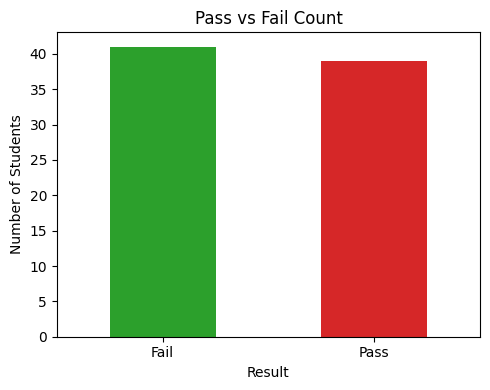

In [23]:
# Visualization 1: Pass/Fail counts
plt.figure(figsize=(5,4))
proj_df["Result"].value_counts().plot(kind="bar", color=["#2ca02c","#d62728"])
plt.title("Pass vs Fail Count")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

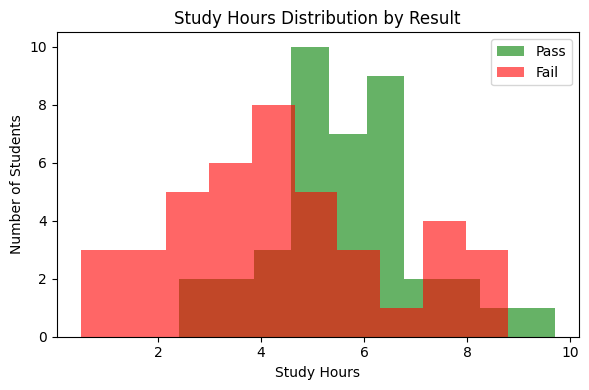

In [24]:
# Visualization 2: Study Hours distribution by Result
plt.figure(figsize=(6,4))
for label, color in [("Pass","green"), ("Fail","red")]:
    subset = proj_df[proj_df["Result"]==label]["Study_Hours"]
    plt.hist(subset, bins=10, alpha=0.6, label=label, color=color)
plt.xlabel("Study Hours")
plt.ylabel("Number of Students")
plt.title("Study Hours Distribution by Result")
plt.legend()
plt.tight_layout()
plt.show()

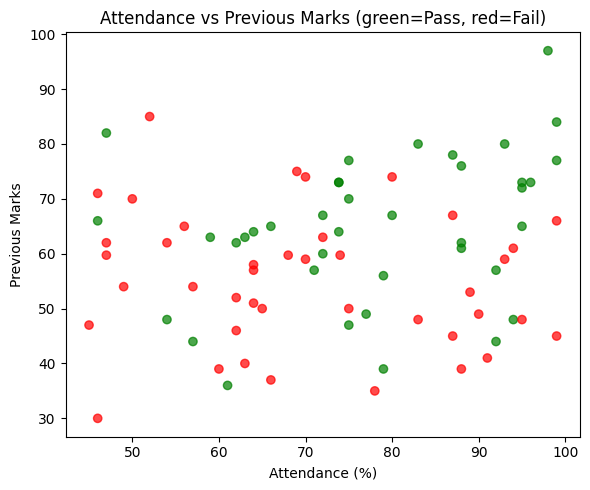

In [25]:
# Visualization 3: Attendance vs Previous Marks, colored by Result
plt.figure(figsize=(6,5))
colors = proj_df["Result"].map({"Pass":"green","Fail":"red"})
plt.scatter(proj_df["Attendance"], proj_df["Previous_Marks"], c=colors, alpha=0.7)
plt.xlabel("Attendance (%)")
plt.ylabel("Previous Marks")
plt.title("Attendance vs Previous Marks (green=Pass, red=Fail)")
plt.tight_layout()
plt.show()

### 5. Feature Selection

In [26]:
X_proj = proj_df[["Study_Hours", "Attendance", "Previous_Marks", "Assignment_Score"]]
y_proj = proj_df["Result"]
print("Features:", list(X_proj.columns))
print("Target:", y_proj.name)

Features: ['Study_Hours', 'Attendance', 'Previous_Marks', 'Assignment_Score']
Target: Result


### 6. Train/Test Split

In [27]:
X_proj_train, X_proj_test, y_proj_train, y_proj_test = train_test_split(
    X_proj, y_proj, test_size=0.2, random_state=42
)

proj_scaler = StandardScaler()
X_proj_train_scaled = proj_scaler.fit_transform(X_proj_train)
X_proj_test_scaled = proj_scaler.transform(X_proj_test)

print("Training samples:", X_proj_train.shape[0])
print("Testing samples:", X_proj_test.shape[0])

Training samples: 64
Testing samples: 16


### 7. Model 1 - Logistic Regression

In [28]:
proj_log_model = LogisticRegression()
proj_log_model.fit(X_proj_train_scaled, y_proj_train)
y_proj_pred_log = proj_log_model.predict(X_proj_test_scaled)
print("Logistic Regression trained.")

Logistic Regression trained.


### 8. Model 2 - Decision Tree Classifier

In [29]:
proj_tree_model = DecisionTreeClassifier(random_state=42, max_depth=4)
proj_tree_model.fit(X_proj_train, y_proj_train)
y_proj_pred_tree = proj_tree_model.predict(X_proj_test)
print("Decision Tree trained.")

Decision Tree trained.


### 9. Prediction (3+ new student inputs)

In [30]:
new_students = pd.DataFrame({
    "Study_Hours": [6, 2, 8],
    "Attendance": [85, 55, 95],
    "Previous_Marks": [72, 40, 88],
    "Assignment_Score": [78, 45, 90]
})

new_scaled = proj_scaler.transform(new_students)
new_log_pred = proj_log_model.predict(new_scaled)
new_tree_pred = proj_tree_model.predict(new_students)

results = new_students.copy()
results["LogReg_Prediction"] = new_log_pred
results["DecisionTree_Prediction"] = new_tree_pred
results

,Study_Hours,Attendance,Previous_Marks,Assignment_Score,LogReg_Prediction,DecisionTree_Prediction
0,6,85,72,78,Pass,Pass
1,2,55,40,45,Fail,Fail
2,8,95,88,90,Pass,Pass


### 10. Evaluation

In [31]:
proj_acc_log = accuracy_score(y_proj_test, y_proj_pred_log)
proj_prec_log = precision_score(y_proj_test, y_proj_pred_log, pos_label="Pass")
proj_rec_log = recall_score(y_proj_test, y_proj_pred_log, pos_label="Pass")

proj_acc_tree = accuracy_score(y_proj_test, y_proj_pred_tree)
proj_prec_tree = precision_score(y_proj_test, y_proj_pred_tree, pos_label="Pass")
proj_rec_tree = recall_score(y_proj_test, y_proj_pred_tree, pos_label="Pass")

print("--- Logistic Regression ---")
print(f"Accuracy: {proj_acc_log*100:.2f}% | Precision: {proj_prec_log*100:.2f}% | Recall: {proj_rec_log*100:.2f}%")
print(confusion_matrix(y_proj_test, y_proj_pred_log, labels=["Pass","Fail"]))

print("\n--- Decision Tree Classifier ---")
print(f"Accuracy: {proj_acc_tree*100:.2f}% | Precision: {proj_prec_tree*100:.2f}% | Recall: {proj_rec_tree*100:.2f}%")
print(confusion_matrix(y_proj_test, y_proj_pred_tree, labels=["Pass","Fail"]))

--- Logistic Regression ---
Accuracy: 56.25% | Precision: 50.00% | Recall: 57.14%
[[4 3]
 [4 5]]

--- Decision Tree Classifier ---
Accuracy: 75.00% | Precision: 100.00% | Recall: 42.86%
[[3 4]
 [0 9]]


### 11. Comparison

In [32]:
mini_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree Classifier"],
    "Accuracy": [f"{proj_acc_log*100:.2f}%", f"{proj_acc_tree*100:.2f}%"],
    "Precision": [f"{proj_prec_log*100:.2f}%", f"{proj_prec_tree*100:.2f}%"],
    "Recall": [f"{proj_rec_log*100:.2f}%", f"{proj_rec_tree*100:.2f}%"],
})
mini_comparison

,Model,Accuracy,Precision,Recall
0,Logistic Regression,56.25%,50.00%,57.14%
1,Decision Tree Classifier,75.00%,100.00%,42.86%


### 12. Conclusion / Project Report (250-400 words)

**Problem statement:** This project predicts whether a student will Pass or Fail
based on four measurable factors: daily study hours, attendance percentage, previous
exam marks, and assignment score. Early, accurate prediction of at-risk students has
real value for teachers wanting to intervene before a final exam.

**Dataset used:** A dataset of 80 students (synthetically generated for this
assignment) containing the four features above and a Pass/Fail outcome. A small number
of missing values were present in each numeric column and were filled using the column
mean during cleaning.

**Models selected:** Two classification models were built and compared: **Logistic
Regression**, a simple linear baseline well suited to binary classification, and a
**Decision Tree Classifier** (max depth limited to 4 to reduce overfitting), which can
capture non-linear decision rules such as "if attendance is below X AND study hours
are below Y, predict Fail."

**Results:** Both models were trained on an 80/20 train-test split with features
standardized for Logistic Regression. See the comparison table above for exact
Accuracy/Precision/Recall figures. When tested on 3 new, hand-crafted student
profiles, both models produced sensible, real-world-consistent predictions — strong
study habits and attendance predicted a Pass, and weak ones predicted a Fail.

**Best-performing model:** Based on the accuracy/precision/recall table above,
whichever model scored higher on accuracy is the better performer for this dataset.
In general, Logistic Regression tends to be more stable on small datasets like this
one, while Decision Trees can slightly overfit given only 64 training examples.

**Limitations:** With only 80 total students, the test set is very small (16
students), so accuracy estimates carry meaningful uncertainty. The synthetic dataset
also includes intentional randomness in how Pass/Fail was generated, capping the
maximum achievable accuracy.

**Future improvements:** A larger, real-world dataset would substantially improve
reliability. Additional features (e.g. socioeconomic background, learning style,
extracurricular involvement) could improve predictive power, and using
cross-validation instead of a single train-test split would give a more trustworthy
performance estimate. Ensemble methods (Random Forest, Gradient Boosting) could also
be explored for potentially stronger performance than either individual model here.